# Task 4 - Full EDA on California Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.shape

(20640, 9)

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

## Visualizations

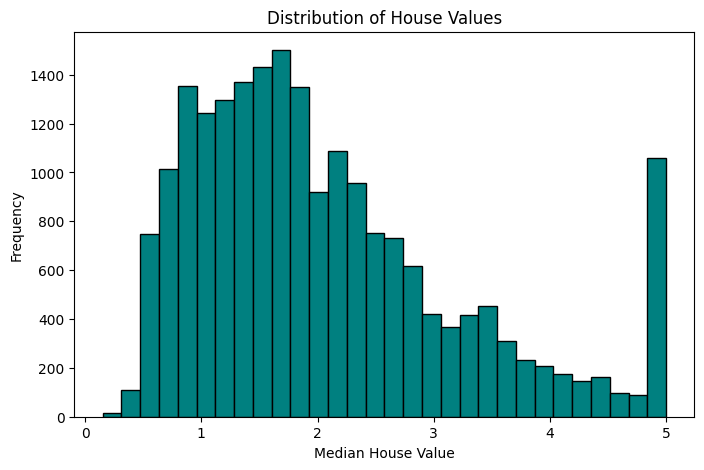

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=30, color="teal", edgecolor="black")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Values")
plt.show()

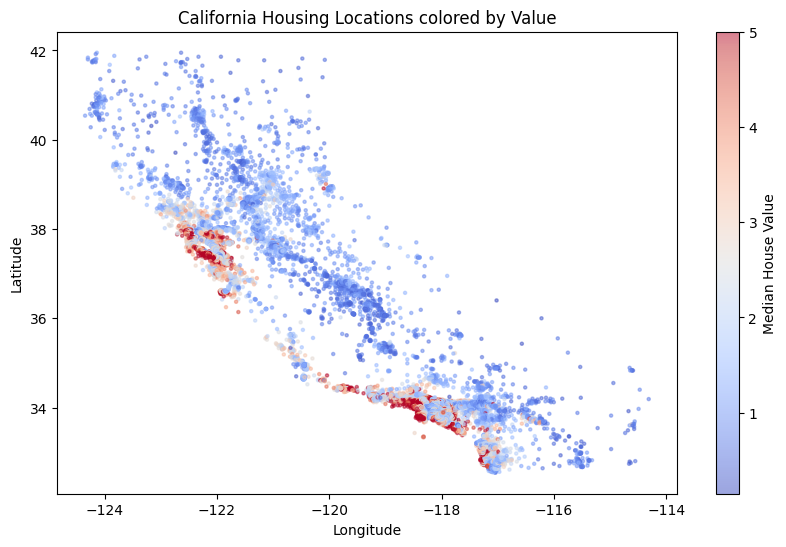

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="coolwarm", s=5, alpha=0.5)
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Locations colored by Value")
plt.show()

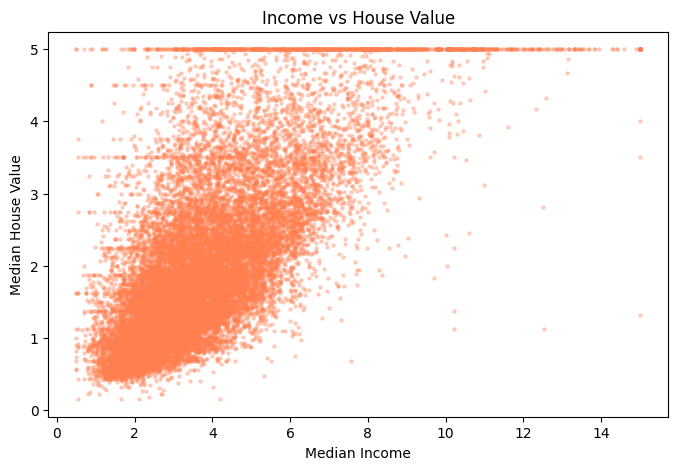

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], s=5, alpha=0.3, color="coral")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Income vs House Value")
plt.show()

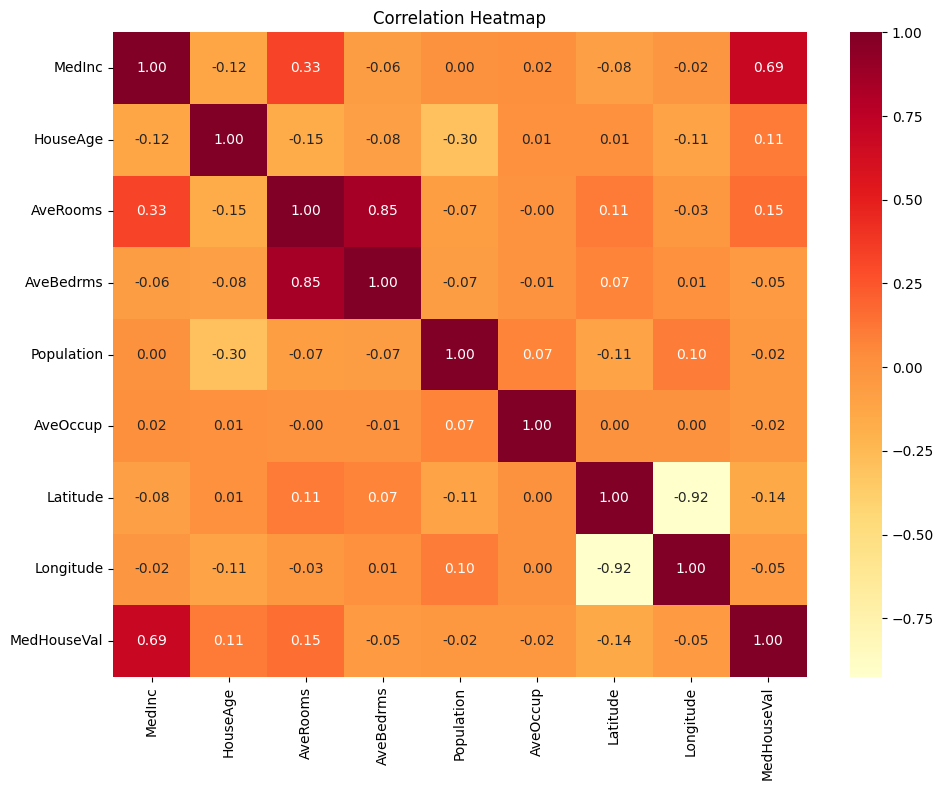

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Groupby Analysis

In [13]:
df["income_group"] = pd.cut(df["MedInc"], bins=[0, 2, 4, 6, 8, 15], labels=["very low", "low", "medium", "high", "very high"])

In [14]:
df.groupby("income_group")["MedHouseVal"].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_26364\2804409066.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_group")["MedHouseVal"].mean()


income_group
very low     1.124972
low          1.681993
medium       2.446352
high         3.448447
very high    4.585956
Name: MedHouseVal, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_26364\3379446164.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_group")["MedHouseVal"].mean().plot(kind="bar", color="steelblue", edgecolor="black", figsize=(8, 5))


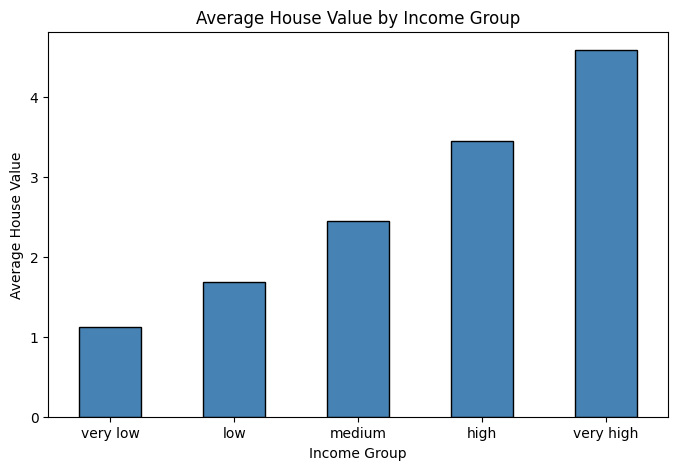

In [15]:
df.groupby("income_group")["MedHouseVal"].mean().plot(kind="bar", color="steelblue", edgecolor="black", figsize=(8, 5))
plt.xlabel("Income Group")
plt.ylabel("Average House Value")
plt.title("Average House Value by Income Group")
plt.xticks(rotation=0)
plt.show()

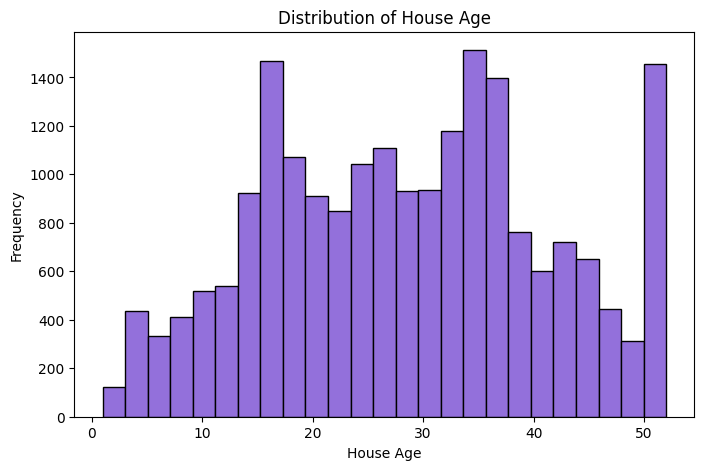

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["HouseAge"], bins=25, color="mediumpurple", edgecolor="black")
plt.xlabel("House Age")
plt.ylabel("Frequency")
plt.title("Distribution of House Age")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_26364\2648781600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="income_group", y="MedHouseVal", data=df, palette="Set2")


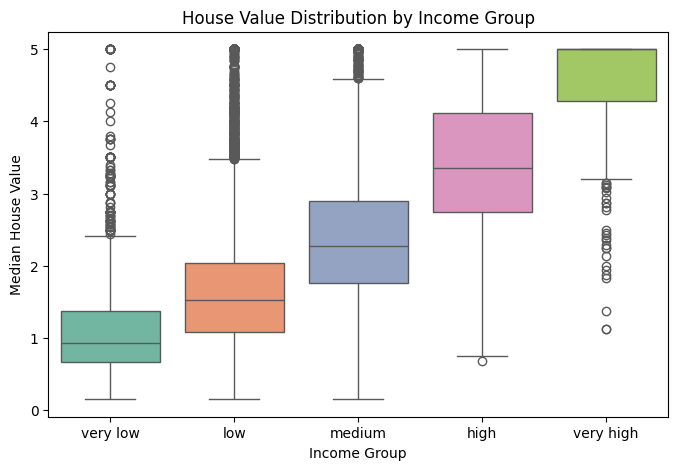

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="income_group", y="MedHouseVal", data=df, palette="Set2")
plt.xlabel("Income Group")
plt.ylabel("Median House Value")
plt.title("House Value Distribution by Income Group")
plt.show()